In [40]:
%matplotlib inline

import random
import math
import time
import os
from os.path import join
import sys
import pandas as pd
pd.set_option('display.max_columns', 500)
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy
import bz2

from nltk.tokenize import sent_tokenize

from nltk.tokenize import TweetTokenizer
from nltk.tokenize import RegexpTokenizer
tweet_tokenize = TweetTokenizer().tokenize
regex_tokenize = RegexpTokenizer(r'\w+').tokenize

import matplotlib.colors as mcolors
import pickle

from tqdm.notebook import tqdm_notebook

#import statsmodels as sm
import statsmodels.api as sm
import scipy.stats as st
from statsmodels.tools.tools import add_constant
from statsmodels.regression.linear_model import OLS
from sklearn import linear_model
from sklearn import preprocessing

emotion_columns = ["surprise", 
                   "love", 
                   "optimism", 
                   "excitement", 
                   "pride", 
                   "relief", 
                   "fear", 
                   "disappointment", 
                   "anger", 
                   "disgust"
            ]

dimensions = emotion_columns
dimensions_redux = emotion_columns
dimensions_names = emotion_columns
dimensions_names_redux = emotion_columns
dims2name = {}

for dim in emotion_columns:
    if dim not in dims2name:
        dims2name[dim] = dim

def ci(x, confidence=0.95):
    avg = np.mean(x)
    low, high = st.t.interval(confidence, len(x)-1, loc=avg, scale=st.sem(x))
    return (avg, high-avg)
    
#dimension-dependent weights
def standardized_dimension_score(x,mu,std):
    zscore = (x-mu)/std
    if zscore >= 0:
        return 1/(1+zscore)
    else:
        zscore = -zscore
        return 2 - (1/(1+zscore))

In [41]:
positive_emotions = ["love", "optimism", "excitement", "pride", "relief"]
negative_emotions = ["fear", "anger", "disgust", "disappointment"]
ambiguous_emotions = ["surprise"]

In [42]:
D = pd.read_csv("../data/paragraph_turns_ekman.csv")
columns_to_remove = [
       'racialJustice',
       'collectiveActionMulti', 'episode_id', 'sentence_length', 'speaker',
       'newSpeaker', 'mfcc1_sma3Mean', 'mfcc2_sma3Mean', 'mfcc3_sma3Mean',
       'mfcc4_sma3Mean', 'F0semitoneFrom27_5Hz_sma3nzMean',
       'F1frequency_sma3nzMean', 'startTime', 'endTime', 'duration',
       'turnCount', 'streak', 'streak_length', 'gratitude', 'excitement',
       'joy', 'neutral', 'approval', 'admiration', 'relief', 'caring',
       'realization', 'pride', 'desire',
       'annoyance', 'amusement', 'confusion', 'sadness', 'curiosity',
       'disapproval', 'nervousness', 'disgust', 'disappointment', 'anger',
       'grief', 'remorse', 'embarrassment', 'ekman'
]
D = D.drop(columns=columns_to_remove)
D.columns

Index(['sentence', 'collectiveAction', 'optimism', 'surprise', 'love', 'fear',
       'problem_solution', 'call_to_action', 'intention', 'execution'],
      dtype='object')

In [43]:
# goekman for anger and disgust
goekman = pd.read_csv("../data/paragraph_turns_new_emotions.csv")
# llama zs
disappointment = pd.read_csv("../data/paragraph_turns_disappointment.csv")
excitement = pd.read_csv("../data/paragraph_turns_excitement.csv")
pride = pd.read_csv("../data/paragraph_turns_pride.csv")
relief = pd.read_csv("../data/paragraph_turns_relief.csv")

In [44]:
D['anger'] = goekman['anger']
D['disgust'] = goekman['disgust']

D['surprise'] = goekman['surprise']
D['love'] = goekman['love']
D['fear'] = goekman['fear']
D['optimism'] = goekman['optimism']

D['disappointment'] = disappointment['disappointment']
D['excitement'] = excitement['excitement']
D['pride'] = pride['pride']
D['relief'] = relief['relief']

In [45]:
D.columns

Index(['sentence', 'collectiveAction', 'optimism', 'surprise', 'love', 'fear',
       'problem_solution', 'call_to_action', 'intention', 'execution', 'anger',
       'disgust', 'disappointment', 'excitement', 'pride', 'relief'],
      dtype='object')

In [46]:
for column in emotion_columns:
    D[f'{column}_weighted'] = D[column].copy()

In [47]:
D['number_of_words'] = D['sentence'].apply(lambda x: len(str(x).split()))
D['log_number_of_words'] = D['number_of_words'].apply(lambda x: np.log(x) if x > 0 else 0)

THRESHOLD

In [48]:
threshold = 0.5
for column in emotion_columns:
    D[f'{column}'] = (D[column] >= threshold).astype(int)

In [49]:
df = D[['collectiveAction'] + ['problem_solution'] + ['call_to_action'] + ['intention'] + ['execution'] + emotion_columns + [f'{col}_weighted' for col in emotion_columns] + ['log_number_of_words']]

In [50]:
df.head(1)

,collectiveAction,problem_solution,call_to_action,intention,execution,surprise,love,optimism,excitement,pride,relief,fear,disappointment,anger,disgust,surprise_weighted,love_weighted,optimism_weighted,excitement_weighted,pride_weighted,relief_weighted,fear_weighted,disappointment_weighted,anger_weighted,disgust_weighted,log_number_of_words
0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,0,0.092119,0.830495,0.964376,0,1,0,0.033691,0,0.048885,0.078114,4.744932


In [51]:
df.to_csv('../data/paragraph_turns_10emotions.csv', index=False)

delta = collective action

++++++++++++surprise
avg. delta : 0.05166150948473026 count delta: 14866
avg. nodelta : 0.018218322201264167 count nodelta: 329229
OR = 2.9356904375038524
#dim-delta=768, #nodim-delta=14098, #dim-nodelta=5998, #nodim-nodelta=323231
++++++++++++love
avg. delta : 0.17691376294901118 count delta: 14866
avg. nodelta : 0.07694036673561563 count nodelta: 329229
OR = 2.5786463651460614
#dim-delta=2630, #nodim-delta=12236, #dim-nodelta=25331, #nodim-nodelta=303898
++++++++++++optimism
avg. delta : 0.7668505314139648 count delta: 14866
avg. nodelta : 0.4527000962855641 count nodelta: 329229
OR = 3.9764092723356868
#dim-delta=11400, #nodim-delta=3466, #dim-nodelta=149042, #nodim-nodelta=180187
++++++++++++excitement
avg. delta : 0.15969325978743443 count delta: 14866
avg. nodelta : 0.12877358920386722 count nodelta: 329229
OR = 1.2857394540601088
#dim-delta=2374, #nodim-delta=12492, #dim-nodelta=42396, #nodim-nodelta=286833
++++++++++++pride
avg. delta : 0.24653571909054217 count delta: 14866
av

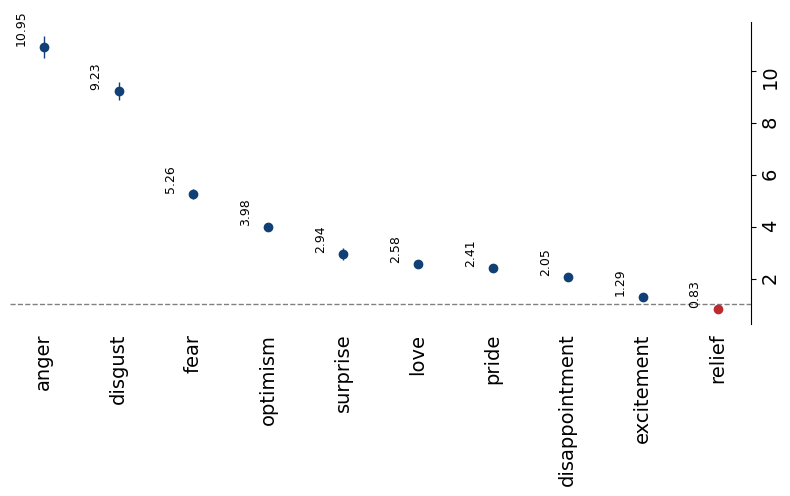

In [52]:
import numpy as np
import matplotlib.pyplot as plt

all_dims = dimensions_names_redux 

def ci(arr):
    arr = np.array(arr.dropna())
    n = len(arr)
    if n == 0:
        return 0, 0
    mean = np.mean(arr)
    se = np.std(arr, ddof=1) / np.sqrt(n)
    ci_val = 1.96 * se
    return mean, ci_val

df_no_delta = df[df['collectiveAction'] == 0].dropna()
df_delta = df[df['collectiveAction'] == 1].dropna()

# Create plot
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
y_oddsratio = []
y_ci_OR = []
y_ratio = []
y_delta = []
y_nodelta = []
y_ci_delta = []
y_ci_nodelta = []
colors = []

for dim in dimensions_names_redux:
    print(f'++++++++++++{dim}')
    
    scores_delta = df_delta[dim]
    scores_no_delta = df_no_delta[dim]

    avg_delta, ci_delta = ci(scores_delta)
    avg_no_delta, ci_no_delta = ci(scores_no_delta)

    print(f'avg. delta : {avg_delta} count delta: {len(scores_delta)}')
    print(f'avg. nodelta : {avg_no_delta} count nodelta: {len(scores_no_delta)}')

    # Avoid division by zero or log(0)
    eps = 1e-6
    avg_delta = np.clip(avg_delta, eps, 1 - eps)
    avg_no_delta = np.clip(avg_no_delta, eps, 1 - eps)

    OR = (avg_delta / (1 - avg_delta)) / (avg_no_delta / (1 - avg_no_delta))
    log_OR = np.log(OR)
    y_oddsratio.append(OR)
    y_ratio.append((avg_delta / avg_no_delta) - 1)
    y_delta.append(avg_delta / avg_no_delta)
    y_nodelta.append(avg_no_delta)
    y_ci_delta.append(ci_delta / avg_no_delta)
    y_ci_nodelta.append(ci_no_delta / avg_no_delta)

    # Get raw counts
    _dim_delta = int(avg_delta * len(scores_delta))
    _no_dim_delta = len(scores_delta) - _dim_delta
    _dim_no_delta = int(avg_no_delta * len(scores_no_delta))
    _no_dim_no_delta = len(scores_no_delta) - _dim_no_delta

    print(f'OR = {OR}')
    print(f'#dim-delta={_dim_delta}, #nodim-delta={_no_dim_delta}, #dim-nodelta={_dim_no_delta}, #nodim-nodelta={_no_dim_no_delta}')
    
    standard_error_log_OR = np.sqrt(1 / (_dim_delta + eps) + 1 / (_no_dim_delta + eps) +
                                    1 / (_dim_no_delta + eps) + 1 / (_no_dim_no_delta + eps))
    ci_log_OR = 1.96 * standard_error_log_OR
    ci_OR_upper = np.exp(log_OR + ci_log_OR)
    ci_OR_lower = np.exp(log_OR - ci_log_OR)
    ci_OR = ci_OR_upper - OR
    y_ci_OR.append(ci_OR)

    if avg_delta > avg_no_delta:
        color = '#104076'  # blue
    else:
        color = '#BD2B30'  # red
    colors.append(color)

# Prepare for plotting
L = list(zip(y_oddsratio, y_ci_OR, y_ratio, y_delta, y_ci_delta, y_nodelta, y_ci_nodelta, colors, dimensions_names_redux))
L.sort(key=lambda x: x[0], reverse=True)

labels_ordered = []
for i, (y_odds, y_odds_ci, y_rat, y_d, err_delta, y_nod, err_nodelta, color, label) in enumerate(L):
    labels_ordered.append(label)
    ax.scatter([i], [y_odds], s=10, color=color)
    ax.errorbar([i], [y_odds], yerr=[y_odds_ci], elinewidth=1, fmt='o', color=color)
    ax.text(i - 0.3, y_odds + 0.05, f'{y_odds:.2f}', ha='center', va='bottom', fontsize=9, color='black', rotation=90)

# Formatting
ax.set_xticks(range(len(labels_ordered)))
ax.set_xticklabels(labels_ordered, fontsize=14, rotation=90)
ax.yaxis.set_ticks_position('right')
ax.axhline(1, linestyle='--', linewidth=1, color='gray')

for tick in ax.get_yticklabels():
    tick.set_fontsize(14)
    tick.set_rotation(90)

ax.spines["bottom"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.xaxis.set_ticks_position("none")

plt.tight_layout()
plt.savefig('../plots/odds_ratio.pdf')
plt.show()

In [53]:
results_data = {
    'emotion': labels_ordered,
    'odds_ratio': [l[0] for l in L],
    'lower_ci': [l[0] - l[1] for l in L],  # odds_ratio - ci
    'upper_ci': [l[0] + l[1] for l in L]   # odds_ratio + ci
}

results_df = pd.DataFrame(results_data)
results_df.to_csv('../plots/odds_ratio.csv', index=False)
print(f"Results saved to '../plots/odds_ratio.csv'")

Results saved to '../plots/odds_ratio.csv'


In [54]:
results_df.columns

Index(['emotion', 'odds_ratio', 'lower_ci', 'upper_ci'], dtype='object')

In [55]:
# Map each emotion to a category
def get_category(emotion):
    if emotion in positive_emotions:
        return "positive"
    elif emotion in negative_emotions:
        return "negative"
    elif emotion in ambiguous_emotions:
        return "ambiguous"
    else:
        return "unknown"

# Add a category column
results_df['category'] = results_df['emotion'].apply(get_category)

# Average the metrics by category
category_means = results_df.groupby('category')[['odds_ratio', 'lower_ci', 'upper_ci']].mean().reset_index()
category_means
category_means.to_csv('../plots/odds_ratio_simple.csv', index=False)
print(f"Results saved!")

Results saved!


++++++++++++surprise
avg. delta : 0.05904095904095904 count delta: 10010
avg. nodelta : 0.01848332011314486 count nodelta: 334085
OR = 3.331964635182655
#dim-delta=591, #nodim-delta=9419, #dim-nodelta=6175, #nodim-nodelta=327910
++++++++++++love
avg. delta : 0.15764235764235765 count delta: 10010
avg. nodelta : 0.07897092057410539 count nodelta: 334085
OR = 2.182642174202079
#dim-delta=1578, #nodim-delta=8432, #dim-nodelta=26383, #nodim-nodelta=307702
++++++++++++optimism
avg. delta : 0.727072927072927 count delta: 10010
avg. nodelta : 0.45845817681129053 count nodelta: 334085
OR = 3.146760108773252
#dim-delta=7278, #nodim-delta=2732, #dim-nodelta=153164, #nodim-nodelta=180921
++++++++++++excitement
avg. delta : 0.13396603396603396 count delta: 10010
avg. nodelta : 0.12999386383704745 count nodelta: 334085
OR = 1.0352833703370554
#dim-delta=1341, #nodim-delta=8669, #dim-nodelta=43428, #nodim-nodelta=290657
++++++++++++pride
avg. delta : 0.2073926073926074 count delta: 10010
avg. nodelt

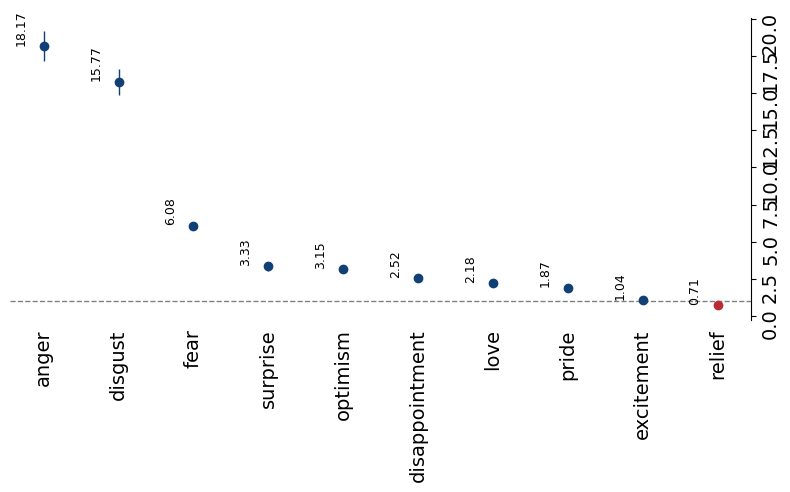

In [56]:
import numpy as np
import matplotlib.pyplot as plt

# Helper function for confidence intervals
def ci(arr):
    arr = np.array(arr.dropna())
    n = len(arr)
    if n == 0:
        return 0, 0
    mean = np.mean(arr)
    se = np.std(arr, ddof=1) / np.sqrt(n)
    ci_val = 1.96 * se
    return mean, ci_val

# Filter your DataFrame
df_no_delta = df[df['problem_solution'] == 0].dropna()
df_delta = df[df['problem_solution'] == 1].dropna()

# Create plot
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
y_oddsratio = []
y_ci_OR = []
y_ratio = []
y_delta = []
y_nodelta = []
y_ci_delta = []
y_ci_nodelta = []
colors = []

for dim in dimensions_names_redux:
    print(f'++++++++++++{dim}')
    
    scores_delta = df_delta[dim]
    scores_no_delta = df_no_delta[dim]

    avg_delta, ci_delta = ci(scores_delta)
    avg_no_delta, ci_no_delta = ci(scores_no_delta)

    print(f'avg. delta : {avg_delta} count delta: {len(scores_delta)}')
    print(f'avg. nodelta : {avg_no_delta} count nodelta: {len(scores_no_delta)}')

    # Avoid division by zero or log(0)
    eps = 1e-6
    avg_delta = np.clip(avg_delta, eps, 1 - eps)
    avg_no_delta = np.clip(avg_no_delta, eps, 1 - eps)

    OR = (avg_delta / (1 - avg_delta)) / (avg_no_delta / (1 - avg_no_delta))
    log_OR = np.log(OR)
    y_oddsratio.append(OR)
    y_ratio.append((avg_delta / avg_no_delta) - 1)
    y_delta.append(avg_delta / avg_no_delta)
    y_nodelta.append(avg_no_delta)
    y_ci_delta.append(ci_delta / avg_no_delta)
    y_ci_nodelta.append(ci_no_delta / avg_no_delta)

    # Get raw counts
    _dim_delta = int(avg_delta * len(scores_delta))
    _no_dim_delta = len(scores_delta) - _dim_delta
    _dim_no_delta = int(avg_no_delta * len(scores_no_delta))
    _no_dim_no_delta = len(scores_no_delta) - _dim_no_delta

    print(f'OR = {OR}')
    print(f'#dim-delta={_dim_delta}, #nodim-delta={_no_dim_delta}, #dim-nodelta={_dim_no_delta}, #nodim-nodelta={_no_dim_no_delta}')
    
    standard_error_log_OR = np.sqrt(1 / (_dim_delta + eps) + 1 / (_no_dim_delta + eps) +
                                    1 / (_dim_no_delta + eps) + 1 / (_no_dim_no_delta + eps))
    ci_log_OR = 1.96 * standard_error_log_OR
    ci_OR_upper = np.exp(log_OR + ci_log_OR)
    ci_OR_lower = np.exp(log_OR - ci_log_OR)
    ci_OR = ci_OR_upper - OR
    y_ci_OR.append(ci_OR)

    if avg_delta > avg_no_delta:
        color = '#104076'  # blue
    else:
        color = '#BD2B30'  # red
    colors.append(color)

# Prepare for plotting
L = list(zip(y_oddsratio, y_ci_OR, y_ratio, y_delta, y_ci_delta, y_nodelta, y_ci_nodelta, colors, dimensions_names_redux))
L.sort(key=lambda x: x[0], reverse=True)

labels_ordered = []
for i, (y_odds, y_odds_ci, y_rat, y_d, err_delta, y_nod, err_nodelta, color, label) in enumerate(L):
    labels_ordered.append(label)
    ax.scatter([i], [y_odds], s=10, color=color)
    ax.errorbar([i], [y_odds], yerr=[y_odds_ci], elinewidth=1, fmt='o', color=color)
    ax.text(i - 0.3, y_odds + 0.05, f'{y_odds:.2f}', ha='center', va='bottom', fontsize=9, color='black', rotation=90)

# Formatting
ax.set_xticks(range(len(labels_ordered)))
ax.set_xticklabels(labels_ordered, fontsize=14, rotation=90)
ax.yaxis.set_ticks_position('right')
ax.axhline(1, linestyle='--', linewidth=1, color='gray')

for tick in ax.get_yticklabels():
    tick.set_fontsize(14)
    tick.set_rotation(90)

ax.spines["bottom"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.xaxis.set_ticks_position("none")

plt.tight_layout()
plt.savefig('../plots/odds_ratio_problem_solution.pdf')
plt.show()

In [57]:
results_data = {
    'emotion': labels_ordered,
    'odds_ratio': [l[0] for l in L],
    'lower_ci': [l[0] - l[1] for l in L],  # odds_ratio - ci
    'upper_ci': [l[0] + l[1] for l in L]   # odds_ratio + ci
}

results_df = pd.DataFrame(results_data)
results_df.to_csv('../plots/odds_ratio_problem_solution.csv', index=False)
print(f"Results saved to '../plots/odds_ratio_problem_solution.csv'")

Results saved to '../plots/odds_ratio_problem_solution.csv'


In [58]:
results_df['category'] = results_df['emotion'].apply(get_category)

# Average the metrics by category
category_means = results_df.groupby('category')[['odds_ratio', 'lower_ci', 'upper_ci']].mean().reset_index()
category_means
category_means.to_csv('../plots/odds_ratio_problem_solution_simple.csv', index=False)
print(f"Results saved!")

Results saved!


In [59]:
odds_problem_solution = pd.DataFrame({
    'Emotion': all_dims, 
    'Odds Ratio': y_oddsratio, 
    'Lower CI': [or_val - ci for or_val, ci in zip(y_oddsratio, y_ci_OR)], 
    'Upper CI': [or_val + ci for or_val, ci in zip(y_oddsratio, y_ci_OR)]
})

odds_problem_solution.head()

,Emotion,Odds Ratio,Lower CI,Upper CI
0,surprise,3.331965,3.029667,3.634262
1,love,2.182642,2.058749,2.306535
2,optimism,3.146760,3.003565,3.289955
3,excitement,1.035283,0.973032,1.097535
4,pride,1.871225,1.776442,1.966008


++++++++++++surprise
avg. delta : 0.06654567453115548 count delta: 1653
avg. nodelta : 0.019436868141174273 count nodelta: 342442
OR = 3.5964665954185158
#dim-delta=110, #nodim-delta=1543, #dim-nodelta=6656, #nodim-nodelta=335786
++++++++++++love
avg. delta : 0.2885662431941924 count delta: 1653
avg. nodelta : 0.08025884675361084 count nodelta: 342442
OR = 4.6481888163502925
#dim-delta=477, #nodim-delta=1176, #dim-nodelta=27484, #nodim-nodelta=314958
++++++++++++optimism
avg. delta : 0.9092558983666061 count delta: 1653
avg. nodelta : 0.46413407233925746 count nodelta: 342442
OR = 11.568589584683425
#dim-delta=1503, #nodim-delta=150, #dim-nodelta=158939, #nodim-nodelta=183503
++++++++++++excitement
avg. delta : 0.2335148215366001 count delta: 1653
avg. nodelta : 0.12961026976831114 count nodelta: 342442
OR = 2.045902972636313
#dim-delta=386, #nodim-delta=1267, #dim-nodelta=44384, #nodim-nodelta=298058
++++++++++++pride
avg. delta : 0.29219600725952816 count delta: 1653
avg. nodelta : 0

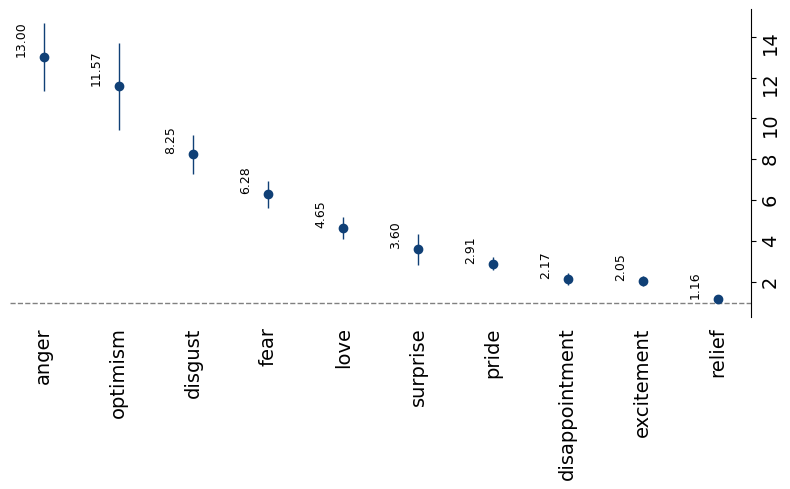

In [60]:
import numpy as np
import matplotlib.pyplot as plt

# Helper function for confidence intervals
def ci(arr):
    arr = np.array(arr.dropna())
    n = len(arr)
    if n == 0:
        return 0, 0
    mean = np.mean(arr)
    se = np.std(arr, ddof=1) / np.sqrt(n)
    ci_val = 1.96 * se
    return mean, ci_val

# Filter your DataFrame
df_no_delta = df[df['call_to_action'] == 0].dropna()
df_delta = df[df['call_to_action'] == 1].dropna()

# Create plot
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
y_oddsratio = []
y_ci_OR = []
y_ratio = []
y_delta = []
y_nodelta = []
y_ci_delta = []
y_ci_nodelta = []
colors = []

for dim in dimensions_names_redux:
    print(f'++++++++++++{dim}')
    
    scores_delta = df_delta[dim]
    scores_no_delta = df_no_delta[dim]

    avg_delta, ci_delta = ci(scores_delta)
    avg_no_delta, ci_no_delta = ci(scores_no_delta)

    print(f'avg. delta : {avg_delta} count delta: {len(scores_delta)}')
    print(f'avg. nodelta : {avg_no_delta} count nodelta: {len(scores_no_delta)}')

    # Avoid division by zero or log(0)
    eps = 1e-6
    avg_delta = np.clip(avg_delta, eps, 1 - eps)
    avg_no_delta = np.clip(avg_no_delta, eps, 1 - eps)

    OR = (avg_delta / (1 - avg_delta)) / (avg_no_delta / (1 - avg_no_delta))
    log_OR = np.log(OR)
    y_oddsratio.append(OR)
    y_ratio.append((avg_delta / avg_no_delta) - 1)
    y_delta.append(avg_delta / avg_no_delta)
    y_nodelta.append(avg_no_delta)
    y_ci_delta.append(ci_delta / avg_no_delta)
    y_ci_nodelta.append(ci_no_delta / avg_no_delta)

    # Get raw counts
    _dim_delta = int(avg_delta * len(scores_delta))
    _no_dim_delta = len(scores_delta) - _dim_delta
    _dim_no_delta = int(avg_no_delta * len(scores_no_delta))
    _no_dim_no_delta = len(scores_no_delta) - _dim_no_delta

    print(f'OR = {OR}')
    print(f'#dim-delta={_dim_delta}, #nodim-delta={_no_dim_delta}, #dim-nodelta={_dim_no_delta}, #nodim-nodelta={_no_dim_no_delta}')
    
    standard_error_log_OR = np.sqrt(1 / (_dim_delta + eps) + 1 / (_no_dim_delta + eps) +
                                    1 / (_dim_no_delta + eps) + 1 / (_no_dim_no_delta + eps))
    ci_log_OR = 1.96 * standard_error_log_OR
    ci_OR_upper = np.exp(log_OR + ci_log_OR)
    ci_OR_lower = np.exp(log_OR - ci_log_OR)
    ci_OR = ci_OR_upper - OR
    y_ci_OR.append(ci_OR)

    if avg_delta > avg_no_delta:
        color = '#104076'  # blue
    else:
        color = '#BD2B30'  # red
    colors.append(color)

# Prepare for plotting
L = list(zip(y_oddsratio, y_ci_OR, y_ratio, y_delta, y_ci_delta, y_nodelta, y_ci_nodelta, colors, dimensions_names_redux))
L.sort(key=lambda x: x[0], reverse=True)

labels_ordered = []
for i, (y_odds, y_odds_ci, y_rat, y_d, err_delta, y_nod, err_nodelta, color, label) in enumerate(L):
    labels_ordered.append(label)
    ax.scatter([i], [y_odds], s=10, color=color)
    ax.errorbar([i], [y_odds], yerr=[y_odds_ci], elinewidth=1, fmt='o', color=color)
    ax.text(i - 0.3, y_odds + 0.05, f'{y_odds:.2f}', ha='center', va='bottom', fontsize=9, color='black', rotation=90)

# Formatting
ax.set_xticks(range(len(labels_ordered)))
ax.set_xticklabels(labels_ordered, fontsize=14, rotation=90)
ax.yaxis.set_ticks_position('right')
ax.axhline(1, linestyle='--', linewidth=1, color='gray')

for tick in ax.get_yticklabels():
    tick.set_fontsize(14)
    tick.set_rotation(90)

ax.spines["bottom"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.xaxis.set_ticks_position("none")

plt.tight_layout()
plt.savefig('../plots/odds_ratio_call_to_action.pdf')
plt.show()

In [61]:
results_data = {
    'emotion': labels_ordered,
    'odds_ratio': [l[0] for l in L],
    'lower_ci': [l[0] - l[1] for l in L],  # odds_ratio - ci
    'upper_ci': [l[0] + l[1] for l in L]   # odds_ratio + ci
}

results_df = pd.DataFrame(results_data)
results_df.to_csv('../plots/odds_ratio_call_to_action.csv', index=False)
print(f"Results saved to '../plots/odds_ratio_call_to_action.csv'")

Results saved to '../plots/odds_ratio_call_to_action.csv'


In [62]:
results_df['category'] = results_df['emotion'].apply(get_category)

# Average the metrics by category
category_means = results_df.groupby('category')[['odds_ratio', 'lower_ci', 'upper_ci']].mean().reset_index()
category_means
category_means.to_csv('../plots/odds_ratio_call_to_action_simple.csv', index=False)
print(f"Results saved!")

Results saved!


In [63]:
odds_call_to_action = pd.DataFrame({
    'Emotion': all_dims, 
    'Odds Ratio': y_oddsratio, 
    'Lower CI': [or_val - ci for or_val, ci in zip(y_oddsratio, y_ci_OR)], 
    'Upper CI': [or_val + ci for or_val, ci in zip(y_oddsratio, y_ci_OR)]
})

++++++++++++surprise
avg. delta : 0.06352087114337568 count delta: 2755
avg. nodelta : 0.019309193179820706 count nodelta: 341340
OR = 3.444976941777547
#dim-delta=175, #nodim-delta=2580, #dim-nodelta=6591, #nodim-nodelta=334749
++++++++++++love
avg. delta : 0.2500907441016334 count delta: 2755
avg. nodelta : 0.07989687701412082 count nodelta: 341340
OR = 3.8405692948197876
#dim-delta=689, #nodim-delta=2066, #dim-nodelta=27272, #nodim-nodelta=314068
++++++++++++optimism
avg. delta : 0.8359346642468239 count delta: 2755
avg. nodelta : 0.46328880295306735 count nodelta: 341340
OR = 5.902613610284712
#dim-delta=2303, #nodim-delta=452, #dim-nodelta=158139, #nodim-nodelta=183201
++++++++++++excitement
avg. delta : 0.21088929219600727 count delta: 2755
avg. nodelta : 0.12945743247202204 count nodelta: 341340
OR = 1.797130501346739
#dim-delta=581, #nodim-delta=2174, #dim-nodelta=44189, #nodim-nodelta=297151
++++++++++++pride
avg. delta : 0.3019963702359347 count delta: 2755
avg. nodelta : 0.1

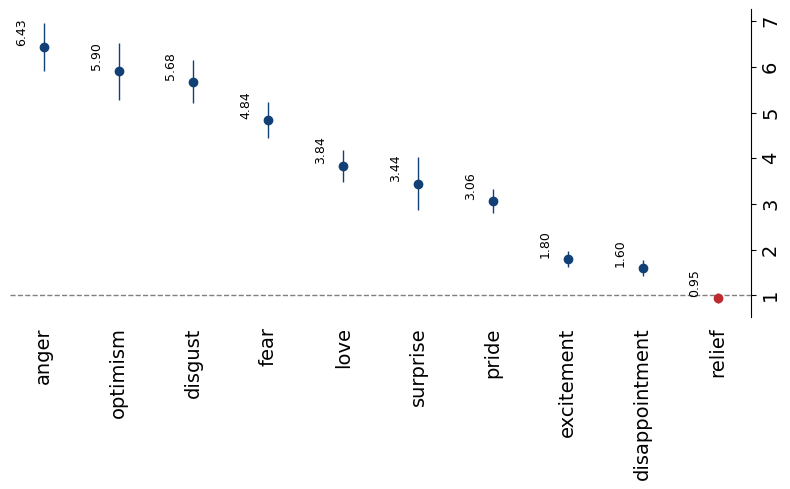

In [64]:
import numpy as np
import matplotlib.pyplot as plt

# Helper function for confidence intervals
def ci(arr):
    arr = np.array(arr.dropna())
    n = len(arr)
    if n == 0:
        return 0, 0
    mean = np.mean(arr)
    se = np.std(arr, ddof=1) / np.sqrt(n)
    ci_val = 1.96 * se
    return mean, ci_val

# Filter your DataFrame
df_no_delta = df[df['intention'] == 0].dropna()
df_delta = df[df['intention'] == 1].dropna()

# Create plot
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
y_oddsratio = []
y_ci_OR = []
y_ratio = []
y_delta = []
y_nodelta = []
y_ci_delta = []
y_ci_nodelta = []
colors = []

for dim in dimensions_names_redux:
    print(f'++++++++++++{dim}')
    
    scores_delta = df_delta[dim]
    scores_no_delta = df_no_delta[dim]

    avg_delta, ci_delta = ci(scores_delta)
    avg_no_delta, ci_no_delta = ci(scores_no_delta)

    print(f'avg. delta : {avg_delta} count delta: {len(scores_delta)}')
    print(f'avg. nodelta : {avg_no_delta} count nodelta: {len(scores_no_delta)}')

    # Avoid division by zero or log(0)
    eps = 1e-6
    avg_delta = np.clip(avg_delta, eps, 1 - eps)
    avg_no_delta = np.clip(avg_no_delta, eps, 1 - eps)

    OR = (avg_delta / (1 - avg_delta)) / (avg_no_delta / (1 - avg_no_delta))
    log_OR = np.log(OR)
    y_oddsratio.append(OR)
    y_ratio.append((avg_delta / avg_no_delta) - 1)
    y_delta.append(avg_delta / avg_no_delta)
    y_nodelta.append(avg_no_delta)
    y_ci_delta.append(ci_delta / avg_no_delta)
    y_ci_nodelta.append(ci_no_delta / avg_no_delta)

    # Get raw counts
    _dim_delta = int(avg_delta * len(scores_delta))
    _no_dim_delta = len(scores_delta) - _dim_delta
    _dim_no_delta = int(avg_no_delta * len(scores_no_delta))
    _no_dim_no_delta = len(scores_no_delta) - _dim_no_delta

    print(f'OR = {OR}')
    print(f'#dim-delta={_dim_delta}, #nodim-delta={_no_dim_delta}, #dim-nodelta={_dim_no_delta}, #nodim-nodelta={_no_dim_no_delta}')
    
    standard_error_log_OR = np.sqrt(1 / (_dim_delta + eps) + 1 / (_no_dim_delta + eps) +
                                    1 / (_dim_no_delta + eps) + 1 / (_no_dim_no_delta + eps))
    ci_log_OR = 1.96 * standard_error_log_OR
    ci_OR_upper = np.exp(log_OR + ci_log_OR)
    ci_OR_lower = np.exp(log_OR - ci_log_OR)
    ci_OR = ci_OR_upper - OR
    y_ci_OR.append(ci_OR)

    if avg_delta > avg_no_delta:
        color = '#104076'  # blue
    else:
        color = '#BD2B30'  # red
    colors.append(color)

# Prepare for plotting
L = list(zip(y_oddsratio, y_ci_OR, y_ratio, y_delta, y_ci_delta, y_nodelta, y_ci_nodelta, colors, dimensions_names_redux))
L.sort(key=lambda x: x[0], reverse=True)

labels_ordered = []
for i, (y_odds, y_odds_ci, y_rat, y_d, err_delta, y_nod, err_nodelta, color, label) in enumerate(L):
    labels_ordered.append(label)
    ax.scatter([i], [y_odds], s=10, color=color)
    ax.errorbar([i], [y_odds], yerr=[y_odds_ci], elinewidth=1, fmt='o', color=color)
    ax.text(i - 0.3, y_odds + 0.05, f'{y_odds:.2f}', ha='center', va='bottom', fontsize=9, color='black', rotation=90)

# Formatting
ax.set_xticks(range(len(labels_ordered)))
ax.set_xticklabels(labels_ordered, fontsize=14, rotation=90)
ax.yaxis.set_ticks_position('right')
ax.axhline(1, linestyle='--', linewidth=1, color='gray')

for tick in ax.get_yticklabels():
    tick.set_fontsize(14)
    tick.set_rotation(90)

ax.spines["bottom"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.xaxis.set_ticks_position("none")

plt.tight_layout()
plt.savefig('../plots/odds_ratio_intention.pdf')
plt.show()

In [65]:
results_data = {
    'emotion': labels_ordered,
    'odds_ratio': [l[0] for l in L],
    'lower_ci': [l[0] - l[1] for l in L],  # odds_ratio - ci
    'upper_ci': [l[0] + l[1] for l in L]   # odds_ratio + ci
}

results_df = pd.DataFrame(results_data)
results_df.to_csv('../plots/odds_ratio_intention.csv', index=False)
print(f"Results saved to '../plots/odds_ratio_intention.csv'")

Results saved to '../plots/odds_ratio_intention.csv'


In [66]:
results_df['category'] = results_df['emotion'].apply(get_category)

# Average the metrics by category
category_means = results_df.groupby('category')[['odds_ratio', 'lower_ci', 'upper_ci']].mean().reset_index()
category_means
category_means.to_csv('../plots/odds_ratio_intention_simple.csv', index=False)
print(f"Results saved!")

Results saved!


In [67]:
odds_intention = pd.DataFrame({
    'Emotion': all_dims, 
    'Odds Ratio': y_oddsratio, 
    'Lower CI': [or_val - ci for or_val, ci in zip(y_oddsratio, y_ci_OR)], 
    'Upper CI': [or_val + ci for or_val, ci in zip(y_oddsratio, y_ci_OR)]
})

++++++++++++surprise
avg. delta : 0.06081789584061517 count delta: 2861
avg. nodelta : 0.01931812187531137 count nodelta: 341234
OR = 3.2873415600463938
#dim-delta=174, #nodim-delta=2687, #dim-nodelta=6592, #nodim-nodelta=334642
++++++++++++love
avg. delta : 0.3079342887102412 count delta: 2861
avg. nodelta : 0.07935903221836042 count nodelta: 341234
OR = 5.161841345508259
#dim-delta=881, #nodim-delta=1980, #dim-nodelta=27080, #nodim-nodelta=314154
++++++++++++optimism
avg. delta : 0.9328905976931143 count delta: 2861
avg. nodelta : 0.46236013996260633 count nodelta: 341234
OR = 16.164356418451412
#dim-delta=2669, #nodim-delta=192, #dim-nodelta=157773, #nodim-nodelta=183461
++++++++++++excitement
avg. delta : 0.22299895141558895 count delta: 2861
avg. nodelta : 0.12933060597713006 count nodelta: 341234
OR = 1.9321159329030455
#dim-delta=638, #nodim-delta=2223, #dim-nodelta=44132, #nodim-nodelta=297102
++++++++++++pride
avg. delta : 0.40650122334847955 count delta: 2861
avg. nodelta : 0

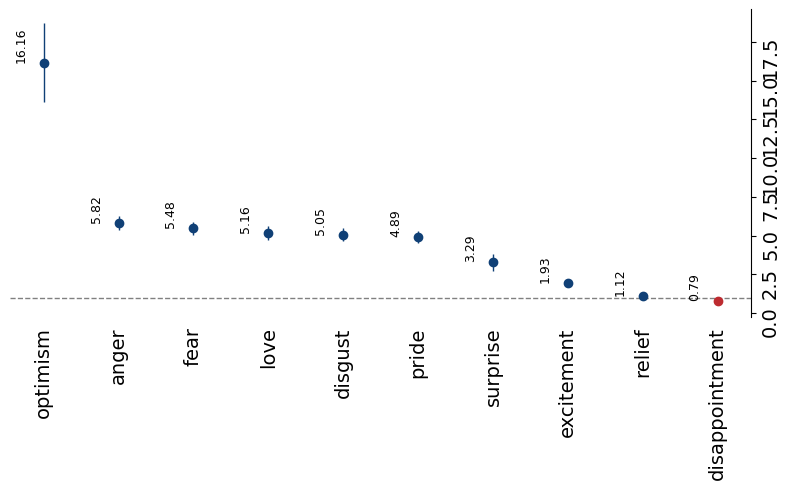

In [68]:
import numpy as np
import matplotlib.pyplot as plt

# Helper function for confidence intervals
def ci(arr):
    arr = np.array(arr.dropna())
    n = len(arr)
    if n == 0:
        return 0, 0
    mean = np.mean(arr)
    se = np.std(arr, ddof=1) / np.sqrt(n)
    ci_val = 1.96 * se
    return mean, ci_val

# Filter your DataFrame
df_no_delta = df[df['execution'] == 0].dropna()
df_delta = df[df['execution'] == 1].dropna()

# Create plot
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
y_oddsratio = []
y_ci_OR = []
y_ratio = []
y_delta = []
y_nodelta = []
y_ci_delta = []
y_ci_nodelta = []
colors = []

for dim in dimensions_names_redux:
    print(f'++++++++++++{dim}')
    
    scores_delta = df_delta[dim]
    scores_no_delta = df_no_delta[dim]

    avg_delta, ci_delta = ci(scores_delta)
    avg_no_delta, ci_no_delta = ci(scores_no_delta)

    print(f'avg. delta : {avg_delta} count delta: {len(scores_delta)}')
    print(f'avg. nodelta : {avg_no_delta} count nodelta: {len(scores_no_delta)}')

    # Avoid division by zero or log(0)
    eps = 1e-6
    avg_delta = np.clip(avg_delta, eps, 1 - eps)
    avg_no_delta = np.clip(avg_no_delta, eps, 1 - eps)

    OR = (avg_delta / (1 - avg_delta)) / (avg_no_delta / (1 - avg_no_delta))
    log_OR = np.log(OR)
    y_oddsratio.append(OR)
    y_ratio.append((avg_delta / avg_no_delta) - 1)
    y_delta.append(avg_delta / avg_no_delta)
    y_nodelta.append(avg_no_delta)
    y_ci_delta.append(ci_delta / avg_no_delta)
    y_ci_nodelta.append(ci_no_delta / avg_no_delta)

    # Get raw counts
    _dim_delta = int(avg_delta * len(scores_delta))
    _no_dim_delta = len(scores_delta) - _dim_delta
    _dim_no_delta = int(avg_no_delta * len(scores_no_delta))
    _no_dim_no_delta = len(scores_no_delta) - _dim_no_delta

    print(f'OR = {OR}')
    print(f'#dim-delta={_dim_delta}, #nodim-delta={_no_dim_delta}, #dim-nodelta={_dim_no_delta}, #nodim-nodelta={_no_dim_no_delta}')
    
    standard_error_log_OR = np.sqrt(1 / (_dim_delta + eps) + 1 / (_no_dim_delta + eps) +
                                    1 / (_dim_no_delta + eps) + 1 / (_no_dim_no_delta + eps))
    ci_log_OR = 1.96 * standard_error_log_OR
    ci_OR_upper = np.exp(log_OR + ci_log_OR)
    ci_OR_lower = np.exp(log_OR - ci_log_OR)
    ci_OR = ci_OR_upper - OR
    y_ci_OR.append(ci_OR)

    if avg_delta > avg_no_delta:
        color = '#104076'  # blue
    else:
        color = '#BD2B30'  # red
    colors.append(color)

# Prepare for plotting
L = list(zip(y_oddsratio, y_ci_OR, y_ratio, y_delta, y_ci_delta, y_nodelta, y_ci_nodelta, colors, dimensions_names_redux))
L.sort(key=lambda x: x[0], reverse=True)

labels_ordered = []
for i, (y_odds, y_odds_ci, y_rat, y_d, err_delta, y_nod, err_nodelta, color, label) in enumerate(L):
    labels_ordered.append(label)
    ax.scatter([i], [y_odds], s=10, color=color)
    ax.errorbar([i], [y_odds], yerr=[y_odds_ci], elinewidth=1, fmt='o', color=color)
    ax.text(i - 0.3, y_odds + 0.05, f'{y_odds:.2f}', ha='center', va='bottom', fontsize=9, color='black', rotation=90)

# Formatting
ax.set_xticks(range(len(labels_ordered)))
ax.set_xticklabels(labels_ordered, fontsize=14, rotation=90)
ax.yaxis.set_ticks_position('right')
ax.axhline(1, linestyle='--', linewidth=1, color='gray')

for tick in ax.get_yticklabels():
    tick.set_fontsize(14)
    tick.set_rotation(90)

ax.spines["bottom"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.xaxis.set_ticks_position("none")

plt.tight_layout()
plt.savefig('../plots/odds_ratio_execution.pdf')
plt.show()

In [69]:
results_data = {
    'emotion': labels_ordered,
    'odds_ratio': [l[0] for l in L],
    'lower_ci': [l[0] - l[1] for l in L],  # odds_ratio - ci
    'upper_ci': [l[0] + l[1] for l in L]   # odds_ratio + ci
}

results_df = pd.DataFrame(results_data)
results_df.to_csv('../plots/odds_ratio_execution.csv', index=False)
print(f"Results saved to '../plots/odds_ratio_execution.csv'")

Results saved to '../plots/odds_ratio_execution.csv'


In [70]:
results_df['category'] = results_df['emotion'].apply(get_category)

# Average the metrics by category
category_means = results_df.groupby('category')[['odds_ratio', 'lower_ci', 'upper_ci']].mean().reset_index()
category_means
category_means.to_csv('../plots/odds_ratio_execution_simple.csv', index=False)
print(f"Results saved!")

Results saved!


In [71]:
odds_execution = pd.DataFrame({
    'Emotion': all_dims, 
    'Odds Ratio': y_oddsratio, 
    'Lower CI': [or_val - ci for or_val, ci in zip(y_oddsratio, y_ci_OR)], 
    'Upper CI': [or_val + ci for or_val, ci in zip(y_oddsratio, y_ci_OR)]
})

Matrix of significant odds ratios

In [72]:
odds_dfs = {
    'Problem-Solution': odds_problem_solution,
    'Call-to-Action': odds_call_to_action,
    'Intention': odds_intention,
    'Execution': odds_execution
}
odds_matrix = pd.DataFrame({'Emotion': odds_problem_solution['Emotion']})

for level, df in odds_dfs.items():
    df_filtered = df[(df['Lower CI'] > 1) | (df['Upper CI'] < 1)]  # Keep only significant odds ratios
    df_filtered = df_filtered[['Emotion', 'Odds Ratio']].rename(columns={'Odds Ratio': level})
    odds_matrix = odds_matrix.merge(df_filtered, on='Emotion', how='left')

odds_matrix
odds_matrix.set_index('Emotion', inplace=True)
odds_matrix

,Problem-Solution,Call-to-Action,Intention,Execution
Emotion,,,,
surprise,3.331965,3.596467,3.444977,3.287342
love,2.182642,4.648189,3.840569,5.161841
optimism,3.146760,11.568590,5.902614,16.164356
excitement,NaN,2.045903,1.797131,1.932116
pride,1.871225,2.907370,3.064542,4.893366
relief,0.714821,1.156615,NaN,1.121409
fear,6.079997,6.284034,4.837680,5.478211
disappointment,2.523263,2.167179,1.601563,0.792823
anger,18.170362,13.001338,6.430791,5.816683


In [73]:
min_value = odds_matrix.min().min()
max_value = odds_matrix.max().max()

print(f"Smallest value: {min_value}")
print(f"Largest value: {max_value}")

Smallest value: 0.7148213635889441
Largest value: 18.170362320774277


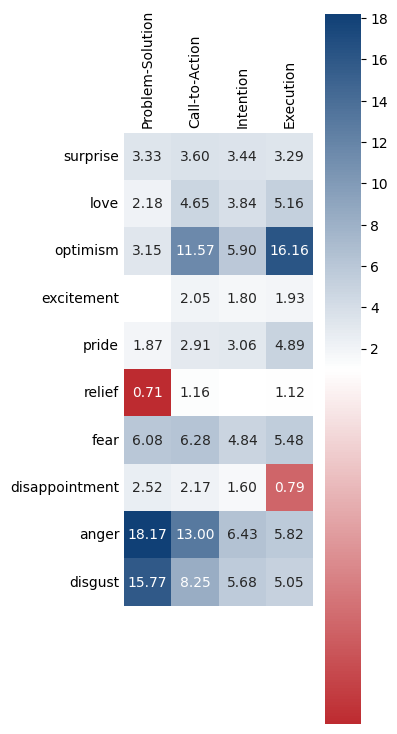

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Filter out rows where all values are NaN
odds_matrix_significant = odds_matrix.dropna(how='all')

# Check if 'Emotion' is the index, if not, set it as the index
if 'Emotion' in odds_matrix_significant.columns:
    odds_matrix_significant = odds_matrix_significant.set_index('Emotion', drop=True)

# Ensure all data is numeric
odds_matrix_significant = odds_matrix_significant.apply(pd.to_numeric, errors='coerce')

# Define a custom diverging colormap with 1.00 centered at white
colors = ["#BD2B30", "white", "#104076"]
custom_cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", colors)

# Use a symmetric scale to center at 1.0
divnorm = mcolors.TwoSlopeNorm(vcenter=1.0)

# Create the heatmap
plt.figure(figsize=(4, 10))
ax = sns.heatmap(
    odds_matrix_significant, 
    annot=True, 
    cmap=custom_cmap, 
    norm=divnorm,  # Ensure white is at 1.00
    fmt=".2f", 
    square=True,
    linewidths=0,  # Remove lines between rows and columns
    #cbar_kws={'label': 'Odds Ratio'},
    xticklabels=True,  # Show x-axis labels (levels of participation)
    yticklabels=True  # Show y-axis labels (emotions)
)

# # Set ticks and labels on colormap from 0.25 to 4 with steps of 0.25
# cbar = ax.collections[0].colorbar
# cbar.set_ticks(np.arange(0.25, 4.25, 0.25))
# cbar.set_ticklabels(np.arange(0.25, 4.25, 0.25).round(2))  # Set tick labels

# Move xticks to top
ax.xaxis.set_ticks_position('top')

# Remove tick marks but keep the labels
ax.tick_params(axis='x', which='both', length=0)  # Remove x-axis tick marks
ax.tick_params(axis='y', which='both', length=0)  # Remove y-axis tick marks

# Ensure x and y axis labels are visible and aligned correctly
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)  # Make sure x labels are not rotated
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)  # Make sure y labels are not rotated



# Remove title and x/y labels
ax.set_title('')
ax.set_xlabel('')
ax.set_ylabel('')

# Show the plot
plt.tight_layout()
plt.savefig('../plots/heatmap.pdf', orientation='landscape')

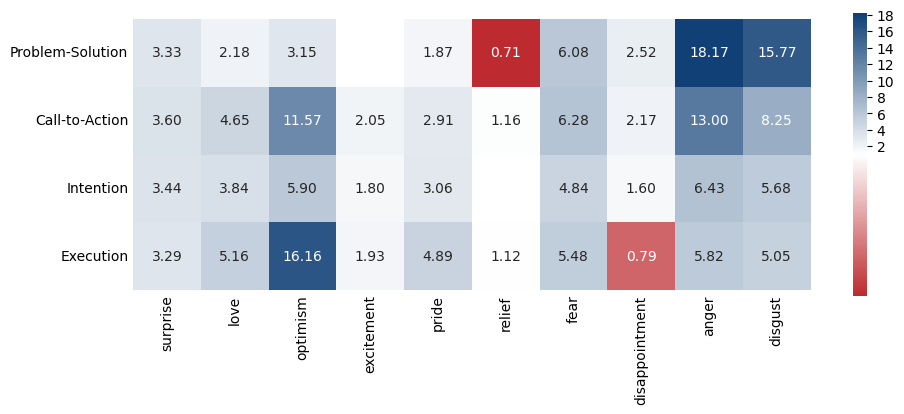

In [75]:
# Transpose the data to switch x and y axes
odds_matrix_significant_transposed = odds_matrix_significant.transpose()

colors = ["#BD2B30", "white", "#104076"]  # Swap blue and red

# Create the heatmap with transposed data
plt.figure(figsize=(10, 4))  # Adjust figure size if needed
ax = sns.heatmap(
    odds_matrix_significant_transposed, 
    annot=True, 
    cmap=custom_cmap, 
    norm=divnorm,  # Ensure white is at 1.00
    fmt=".2f", 
    square=True,
    linewidths=0,  # Remove lines between rows and columns
    xticklabels=True,  # Show x-axis labels (levels of participation)
    yticklabels=True  # Show y-axis labels (emotions)
)

# Move yticks to the left (default)
ax.yaxis.set_ticks_position('left')

# Remove tick marks but keep the labels
ax.tick_params(axis='x', which='both', length=0)  # Remove x-axis tick marks
ax.tick_params(axis='y', which='both', length=0)  # Remove y-axis tick marks

# Ensure x and y axis labels are visible and aligned correctly
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)  # Make sure x labels are not rotated
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)  # Make sure y labels are not rotated

# Remove title and x/y labels
ax.set_title('')
ax.set_xlabel('')
ax.set_ylabel('')

# Show the plot
plt.tight_layout()
plt.savefig('../plots/heatmap.pdf', orientation='landscape')


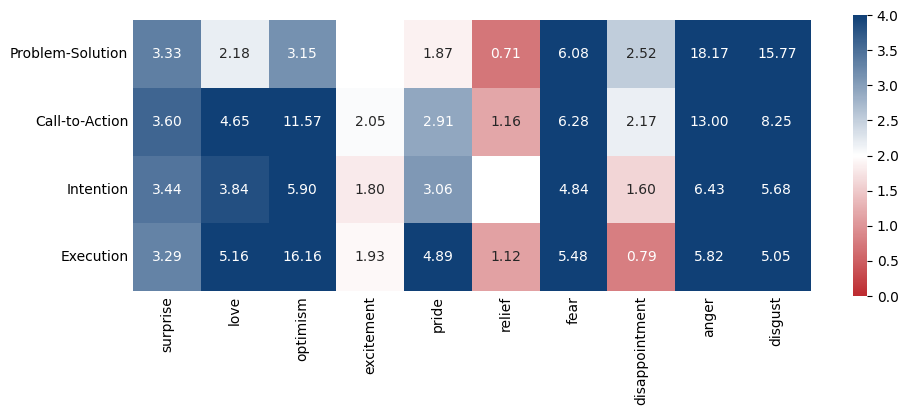

In [76]:
# Define a custom diverging colormap with 1.00 centered at white, but switch blue and red
colors = ["#BD2B30", "white", "#104076"]  # Swap blue and red
custom_cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", colors)

# Use a symmetric scale to center at 2.0, while keeping 1.0 as white
divnorm = mcolors.TwoSlopeNorm(vmin=0, vcenter=2.0, vmax=4)

# Create the heatmap with transposed data and updated colormap
plt.figure(figsize=(10, 4))  # Adjust figure size if needed
ax = sns.heatmap(
    odds_matrix_significant_transposed, 
    annot=True, 
    cmap=custom_cmap, 
    norm=divnorm,  # Set center of colormap to 2.0
    fmt=".2f", 
    square=True,
    linewidths=0,  # Remove lines between rows and columns
    xticklabels=True,  # Show x-axis labels (levels of participation)
    yticklabels=True  # Show y-axis labels (emotions)
)

# Move yticks to the left (default)
ax.yaxis.set_ticks_position('left')

# Remove tick marks but keep the labels
ax.tick_params(axis='x', which='both', length=0)  # Remove x-axis tick marks
ax.tick_params(axis='y', which='both', length=0)  # Remove y-axis tick marks

# Ensure x and y axis labels are visible and aligned correctly
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)  # Make sure x labels are not rotated
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)  # Make sure y labels are not rotated

# Remove title and x/y labels
ax.set_title('')
ax.set_xlabel('')
ax.set_ylabel('')

# Show the plot
plt.tight_layout()
plt.savefig('../plots/heatmap.pdf', orientation='landscape')

In [77]:
# import seaborn as sns
# import matplotlib.pyplot as plt
# import matplotlib.colors as mcolors

# # Filter out rows where all values are NaN
# odds_matrix_significant = odds_matrix.dropna(how='all')

# # Check if 'Emotion' is the index, if not, set it as the index
# if 'Emotion' in odds_matrix_significant.columns:
#     odds_matrix_significant = odds_matrix_significant.set_index('Emotion', drop=True)

# # Ensure all data is numeric
# odds_matrix_significant = odds_matrix_significant.apply(pd.to_numeric, errors='coerce')

# # Define a custom colormap
# colors = ["#BD2B30", "white", "#104076"]  # Red for -3, white for 1, blue for 5
# custom_cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", colors)

# # Define the custom normalization with the vmin and vmax parameters
# norm = mcolors.Normalize(vmin=0, vmax=5)

# # Create the heatmap
# plt.figure(figsize=(10, 8))
# ax = sns.heatmap(
#     odds_matrix_significant, 
#     annot=True, 
#     cmap=custom_cmap,  # Apply the custom colormap
#     norm=norm,  # Use the custom normalization
#     fmt=".2f", 
#     linewidths=0,  # Remove lines between rows and columns
#     cbar_kws={'label': 'Odds Ratio'},
#     xticklabels=True,  # Show x-axis labels (levels of participation)
#     yticklabels=True  # Show y-axis labels (emotions)
# )

# # Move xticks to top
# ax.xaxis.set_ticks_position('top')

# # Remove tick marks but keep the labels
# ax.tick_params(axis='x', which='both', length=0)  # Remove x-axis tick marks
# ax.tick_params(axis='y', which='both', length=0)  # Remove y-axis tick marks

# # Ensure x and y axis labels are visible and aligned correctly
# ax.set_xticklabels(ax.get_xticklabels(), rotation=0)  # Make sure x labels are not rotated
# ax.set_yticklabels(ax.get_yticklabels(), rotation=0)  # Make sure y labels are not rotated

# # Remove title and x/y labels
# ax.set_title('')
# ax.set_xlabel('')
# ax.set_ylabel('')

# # Show the plot
# plt.tight_layout()
# plt.show()

In [78]:
# import seaborn as sns
# import matplotlib.pyplot as plt
# import matplotlib.colors as mcolors
# import numpy as np

# # Filter out rows where all values are NaN
# odds_matrix_significant = odds_matrix.dropna(how='all')

# # Check if 'Emotion' is the index, if not, set it as the index
# if 'Emotion' in odds_matrix_significant.columns:
#     odds_matrix_significant = odds_matrix_significant.set_index('Emotion', drop=True)

# # Ensure all data is numeric
# odds_matrix_significant = odds_matrix_significant.apply(pd.to_numeric, errors='coerce')

# # Define a custom colormap
# colors = ["#BD2B30", "white", "#104076"]  # Red for the smallest value, white for 1, blue for the largest value
# custom_cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", colors)

# # Get the smallest and largest values in the matrix
# vmin = odds_matrix_significant.min().min()  # smallest value in the dataframe
# vmax = odds_matrix_significant.max().max()  # largest value in the dataframe

# # Define custom boundaries and normalization
# boundaries = [vmin, 1, vmax]  # Define custom bins for color mapping
# norm = mcolors.BoundaryNorm(boundaries, custom_cmap.N)

# # Create the heatmap
# plt.figure(figsize=(10, 8))
# ax = sns.heatmap(
#     odds_matrix_significant, 
#     annot=True, 
#     cmap=custom_cmap,  # Apply the custom colormap
#     norm=norm,  # Use the custom normalization with boundaries
#     fmt=".2f", 
#     linewidths=0,  # Remove lines between rows and columns
#     cbar_kws={'label': 'Odds Ratio'},
#     xticklabels=True,  # Show x-axis labels (levels of participation)
#     yticklabels=True  # Show y-axis labels (emotions)
# )

# # Move xticks to top
# ax.xaxis.set_ticks_position('top')

# # Remove tick marks but keep the labels
# ax.tick_params(axis='x', which='both', length=0)  # Remove x-axis tick marks
# ax.tick_params(axis='y', which='both', length=0)  # Remove y-axis tick marks

# # Ensure x and y axis labels are visible and aligned correctly
# ax.set_xticklabels(ax.get_xticklabels(), rotation=0)  # Make sure x labels are not rotated
# ax.set_yticklabels(ax.get_yticklabels(), rotation=0)  # Make sure y labels are not rotated

# # Remove title and x/y labels
# ax.set_title('')
# ax.set_xlabel('')
# ax.set_ylabel('')

# # Show the plot
# plt.tight_layout()
# plt.show()
